In [1]:
import numpy as np
import importlib
import matplotlib.pyplot as plt

import modules.constants
import modules.utils
import modules.loaddata
import modules.interpolation_preprocess

In [2]:
q, data = modules.loaddata.load_response_functions("../week4/results/", "responses_C12_CC_LFG")

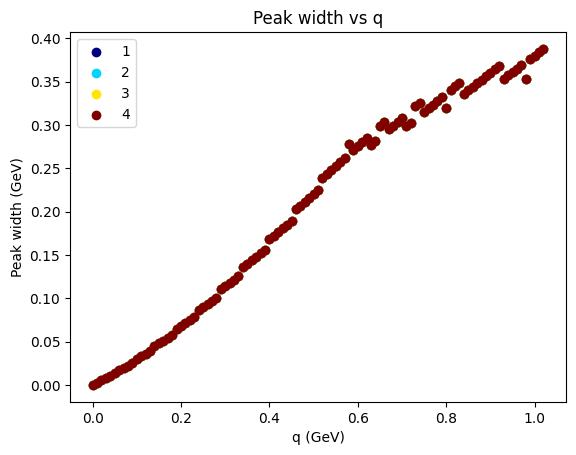

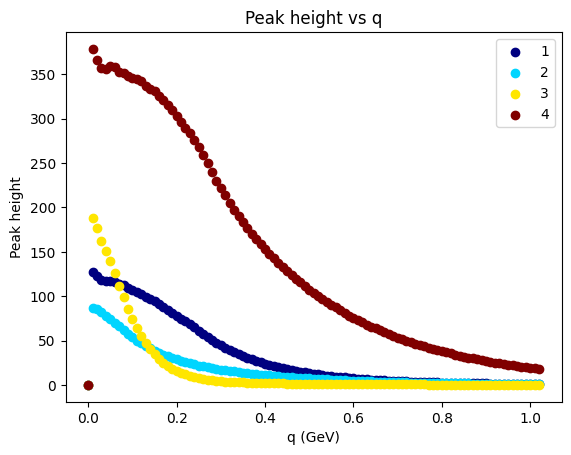

In [8]:
importlib.reload(modules.interpolation_preprocess)

widths = [[] for _ in range(4)]
heights = [[] for _ in range(4)]
for (i, (qval, dval)) in enumerate(zip(q, data)):
    for curve in range(1,5):
        # plt.plot(dval[:,0], dval[:,curve], label=f"q={qval:.2f} GeV, curve={curve}")
        width = modules.interpolation_preprocess.get_peak_width(dval[:,0], dval[:,curve])
        widths[curve-1].append(width)
        heights[curve-1].append(np.max(dval[:,curve]))
    
widths = np.array(widths)
heights = np.array(heights)

colors = modules.utils.generate_colourscale(len(widths))
for i, width in enumerate(widths):
    plt.scatter(q, width, color=colors[i], label=f"{i+1}")

plt.xlabel("q (GeV)")
plt.ylabel("Peak width (GeV)")
plt.legend()
plt.title("Peak width vs q")
plt.show()

for i, height in enumerate(heights):
    plt.scatter(q, height, color=colors[i], label=f"{i+1}")
plt.xlabel("q (GeV)")
plt.ylabel("Peak height")
plt.legend()
plt.title("Peak height vs q")
plt.show()